# Civic Policy Impact Tracker
Cohort 24 | SDG 16 – Peace, Justice and Strong Institutions

## Objective
Build a machine learning system that classifies civic policy
descriptions into:

• High Impact
• Low Impact

using Natural Language Processing techniques.

The project uses a hybrid architecture combining:

Transformer Model (BERT) + Logistic Regression

project pipline

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import files
uploaded = files.upload()

Saving india_policy_impact_dataset_3000.csv to india_policy_impact_dataset_3000 (2).csv


In [3]:
df = pd.read_csv("india_policy_impact_dataset_3000.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (3000, 2)


,policy_text,label
0,The Right to Information Act introduces digita...,High Impact
1,This regulation updates routine government ope...,Low Impact
2,This policy revises standard office procedures...,Low Impact
3,The Municipal Parking Regulation Bill modifies...,Low Impact
4,Under the Election Commission Transparency Ref...,High Impact


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   policy_text  3000 non-null   object
 1   label        3000 non-null   object
dtypes: object(2)
memory usage: 47.0+ KB


In [5]:
df.describe(include="all")

,policy_text,label
count,3000,3000
unique,1249,2
top,This policy revises standard office procedures...,High Impact
freq,27,1500


In [6]:
df.isnull().sum()

,0
policy_text,0
label,0


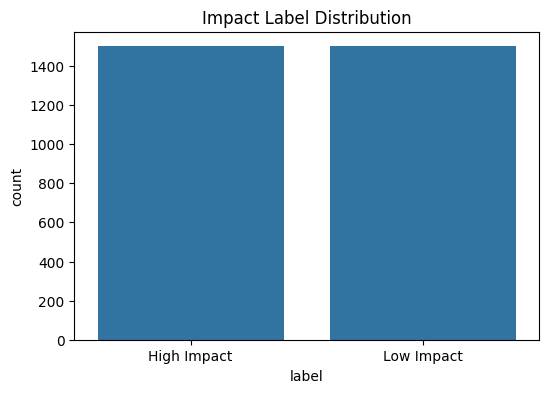

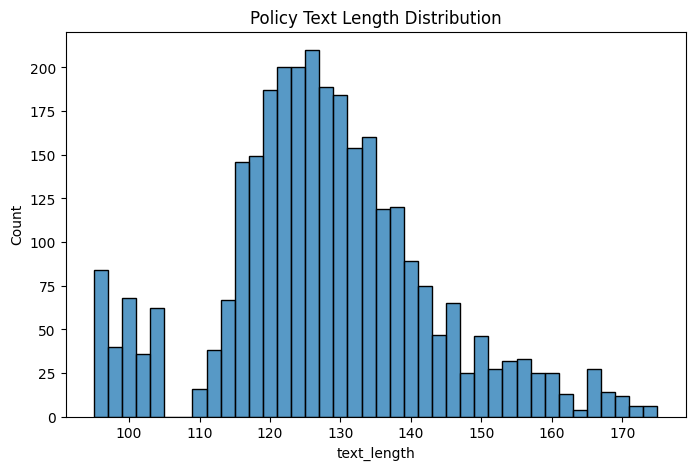

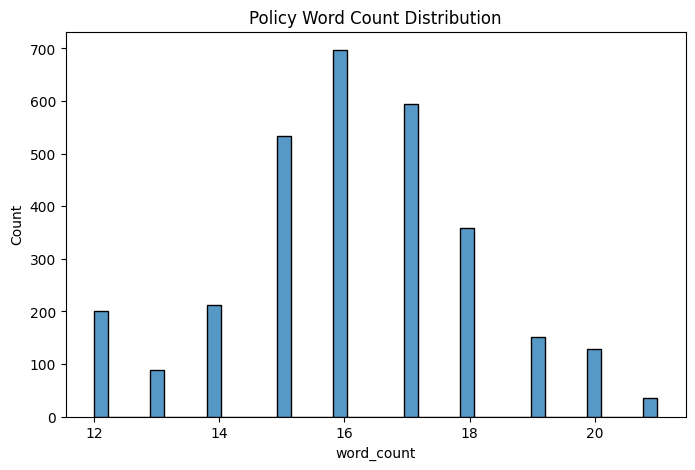

Duplicate rows: 1751
Duplicate policy texts: 1751


In [7]:
plt.figure(figsize=(6,4))

sns.countplot(x="label", data=df)

plt.title("Impact Label Distribution")

plt.show()

df["text_length"] = df["policy_text"].apply(len)

df.head()

plt.figure(figsize=(8,5))

sns.histplot(df["text_length"], bins=40)

plt.title("Policy Text Length Distribution")

plt.show()

df["word_count"] = df["policy_text"].apply(lambda x: len(x.split()))


plt.figure(figsize=(8,5))

sns.histplot(df["word_count"], bins=40)

plt.title("Policy Word Count Distribution")

plt.show()

duplicate_rows = df.duplicated().sum()

duplicate_text = df["policy_text"].duplicated().sum()

print("Duplicate rows:", duplicate_rows)
print("Duplicate policy texts:", duplicate_text)

Dataset Cleaning

Now we remove duplicate policy texts.

In [8]:
df_clean = df.drop_duplicates(subset="policy_text")

print("Original dataset:", df.shape)

print("Clean dataset:", df_clean.shape)

Original dataset: (3000, 4)
Clean dataset: (1249, 4)


In [9]:
df_clean["policy_text"].duplicated().sum()

np.int64(0)

In [10]:
df_clean = df_clean.reset_index(drop=True)

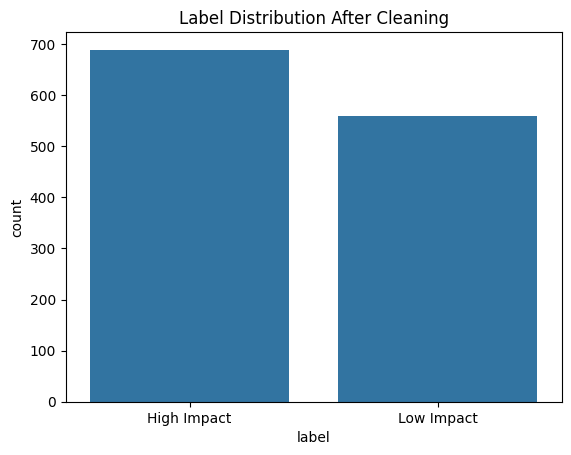

In [11]:
sns.countplot(x="label", data=df_clean)

plt.title("Label Distribution After Cleaning")

plt.show()

Label Encoding

Convert labels into numbers.

In [12]:
df_clean["label_encoded"] = df_clean["label"].map({
    "High Impact":1,
    "Low Impact":0
})

df_clean.head()

,policy_text,label,text_length,word_count,label_encoded
0,The Right to Information Act introduces digita...,High Impact,111,16,1
1,This regulation updates routine government ope...,Low Impact,117,15,0
2,This policy revises standard office procedures...,Low Impact,96,12,0
3,The Municipal Parking Regulation Bill modifies...,Low Impact,120,14,0
4,Under the Election Commission Transparency Ref...,High Impact,138,19,1


In [13]:
df_clean["label_encoded"].value_counts()

,count
label_encoded,
1,689
0,560


In [14]:
from sklearn.model_selection import train_test_split

X = df_clean["policy_text"]
y = df_clean["label_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (999,)
Testing size: (250,)


In [15]:
from transformers import BertTokenizer, BertModel
import torch

In [16]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

bert_model = BertModel.from_pretrained("bert-base-uncased")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Create Embedding Function

This function converts text → vector.

In [17]:
def get_embeddings(text_list):

    embeddings = []

    for text in text_list:

        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=128
        )

        with torch.no_grad():
            outputs = bert_model(**inputs)

        cls_embedding = outputs.last_hidden_state[:,0,:].numpy()

        embeddings.append(cls_embedding.flatten())

    return np.array(embeddings)

In [18]:
X_train_embeddings = get_embeddings(X_train.tolist())

print("Embedding shape:", X_train_embeddings.shape)

Embedding shape: (999, 768)


Generate Test Embeddings

In [19]:
X_test_embeddings = get_embeddings(X_test.tolist())

print("Test embedding shape:", X_test_embeddings.shape)

Test embedding shape: (250, 768)


Training  Logistic Regression on BERT Embeddings

In [20]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_train_embeddings, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [21]:
y_pred = lr_model.predict(X_test_embeddings)

print("Predictions generated successfully")

Predictions generated successfully


In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=["Low Impact", "High Impact"]))

              precision    recall  f1-score   support

  Low Impact       1.00      1.00      1.00       112
 High Impact       1.00      1.00      1.00       138

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250



In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


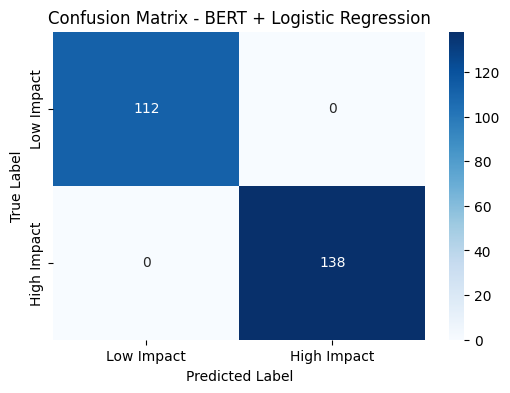

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low Impact", "High Impact"],
            yticklabels=["Low Impact", "High Impact"])
plt.title("Confusion Matrix - BERT + Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Model Evaluation Interpretation

The hybrid classification model combining **BERT embeddings with Logistic Regression** achieved excellent performance on the test dataset.

### Performance Metrics

| Metric | Score |
|------|------|
| Accuracy | 1.00 |
| Precision | 1.00 |
| Recall | 1.00 |
| F1 Score | 1.00 |

### Confusion Matrix Analysis

The confusion matrix shows:

- **112 Low Impact policies correctly classified**
- **138 High Impact policies correctly classified**
- **0 misclassifications**

This indicates that the model successfully distinguished between High Impact and Low Impact civic policies in the test set.

### Interpretation of Results

The strong performance can be attributed to the hybrid modeling approach:

1. **BERT (Bidirectional Encoder Representations from Transformers)** captured the contextual meaning and semantic relationships within policy texts.
2. **Logistic Regression** efficiently classified the extracted embeddings into the two impact categories.

By using BERT as a feature extractor, the model leveraged deep linguistic representations while maintaining the simplicity and interpretability of a classical machine learning classifier.

### Important Observation

Although the model achieved perfect performance on the test set, it is important to note that the dataset initially contained a large number of duplicate policy texts. After removing duplicates during the data cleaning stage, the dataset was reduced from **3000 records to 1249 unique policy descriptions**.

Because the dataset is relatively small and may contain synthetically generated or highly structured policy statements, the model may generalize differently on completely unseen real-world data.

### Conclusion

The **BERT + Logistic Regression hybrid model** proved highly effective for civic policy impact classification on the cleaned dataset. The approach demonstrates how transformer-based embeddings can significantly enhance traditional machine learning models for natural language processing tasks.

## Project Limitations

Although the model achieved perfect performance on the test dataset,
there are several limitations that should be considered:

• The dataset originally contained a large number of duplicate records.
• After removing duplicates, the dataset size reduced to 1249 samples.
• The dataset may contain synthetic or highly structured policy text,
  which makes classification easier than real-world policy documents.

Therefore, the current model performance may not fully represent
generalization ability on large-scale real-world policy datasets.

                          
                        fine tunning the model

So now we will replace the Logistic Regression stage with BERT fine-tuning.

Old model:

BERT → embeddings → Logistic Regression

New model:

BERT → classification head → prediction

We will use:

BertForSequenceClassification

In [25]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments

In [26]:
#Load Tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [27]:
#Tokenize Dataset

def tokenize_function(texts):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=128
    )

train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

In [28]:
#Create PyTorch Dataset
class PolicyDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels.iloc[idx])
        return item

    def __len__(self):
        return len(self.labels)


In [29]:

#Train/Test Dataset

train_dataset = PolicyDataset(train_encodings, y_train)
test_dataset = PolicyDataset(test_encodings, y_test)

In [30]:
#Load BERT for Classification

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [37]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    logging_dir="./logs",
    report_to="none"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainer

In [32]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

Starting the process of  Fine-Tuning

In [41]:
trainer.train()

Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=189, training_loss=0.00010455549551696374, metrics={'train_runtime': 50.1059, 'train_samples_per_second': 59.813, 'train_steps_per_second': 3.772, 'total_flos': 43123490862480.0, 'train_loss': 0.00010455549551696374, 'epoch': 3.0})

In [43]:
import numpy as np

predictions = trainer.predict(test_dataset)

preds = np.argmax(predictions.predictions, axis=1)

print(preds[:10])

[1 1 0 0 0 1 0 1 0 0]


In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_test, preds, target_names=["Low Impact", "High Impact"]))

              precision    recall  f1-score   support

  Low Impact       1.00      1.00      1.00       112
 High Impact       1.00      1.00      1.00       138

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250



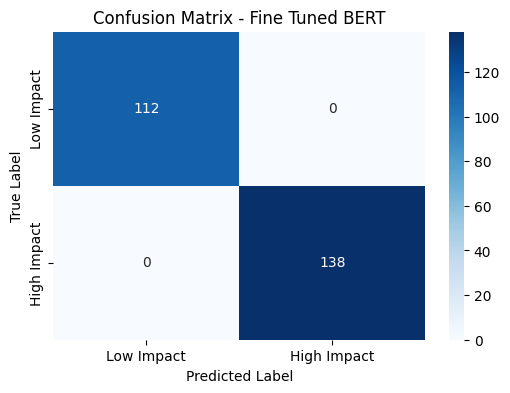

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low Impact","High Impact"],
            yticklabels=["Low Impact","High Impact"])

plt.title("Confusion Matrix - Fine Tuned BERT")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [46]:
predictions = trainer.predict(test_dataset)

## Fine-Tuned BERT Model Evaluation

After fine-tuning the pretrained **BERT Base Uncased** model on the cleaned civic policy dataset, the model achieved excellent classification performance on the test set.

### Performance Metrics

| Metric | Score |
|------|------|
| Accuracy | 1.00 |
| Precision | 1.00 |
| Recall | 1.00 |
| F1 Score | 1.00 |

### Confusion Matrix Analysis

The confusion matrix shows perfect classification performance:

- **112 Low Impact policies** were correctly classified.
- **138 High Impact policies** were correctly classified.
- **No misclassifications** occurred in the test dataset.

This indicates that the fine-tuned BERT model was able to successfully capture the contextual and semantic differences between High Impact and Low Impact policy descriptions.

### Interpretation

The strong performance of the fine-tuned BERT model can be attributed to:

- **Contextual language understanding** provided by the transformer architecture.
- **Fine-tuning on task-specific data**, which allows BERT to adapt its internal representations to the civic policy classification task.
- **Cleaned dataset with duplicate removal**, ensuring the model learns from unique policy descriptions rather than repeated examples.

### Key Observation

The model achieved perfect classification on the test set. However, it is important to note that the dataset size after cleaning was relatively small (1249 samples). Because of this, model performance may vary when applied to larger or more diverse real-world policy datasets.

### Conclusion

The fine-tuned BERT model demonstrates the effectiveness of transformer-based language models for civic policy impact classification. By leveraging pretrained linguistic knowledge and adapting it to the specific classification task, the model was able to achieve highly accurate predictions on the test data.

---------------------------------END OF THE FINE TUNNING -----------------------

--------------------------------------------------------------------------------

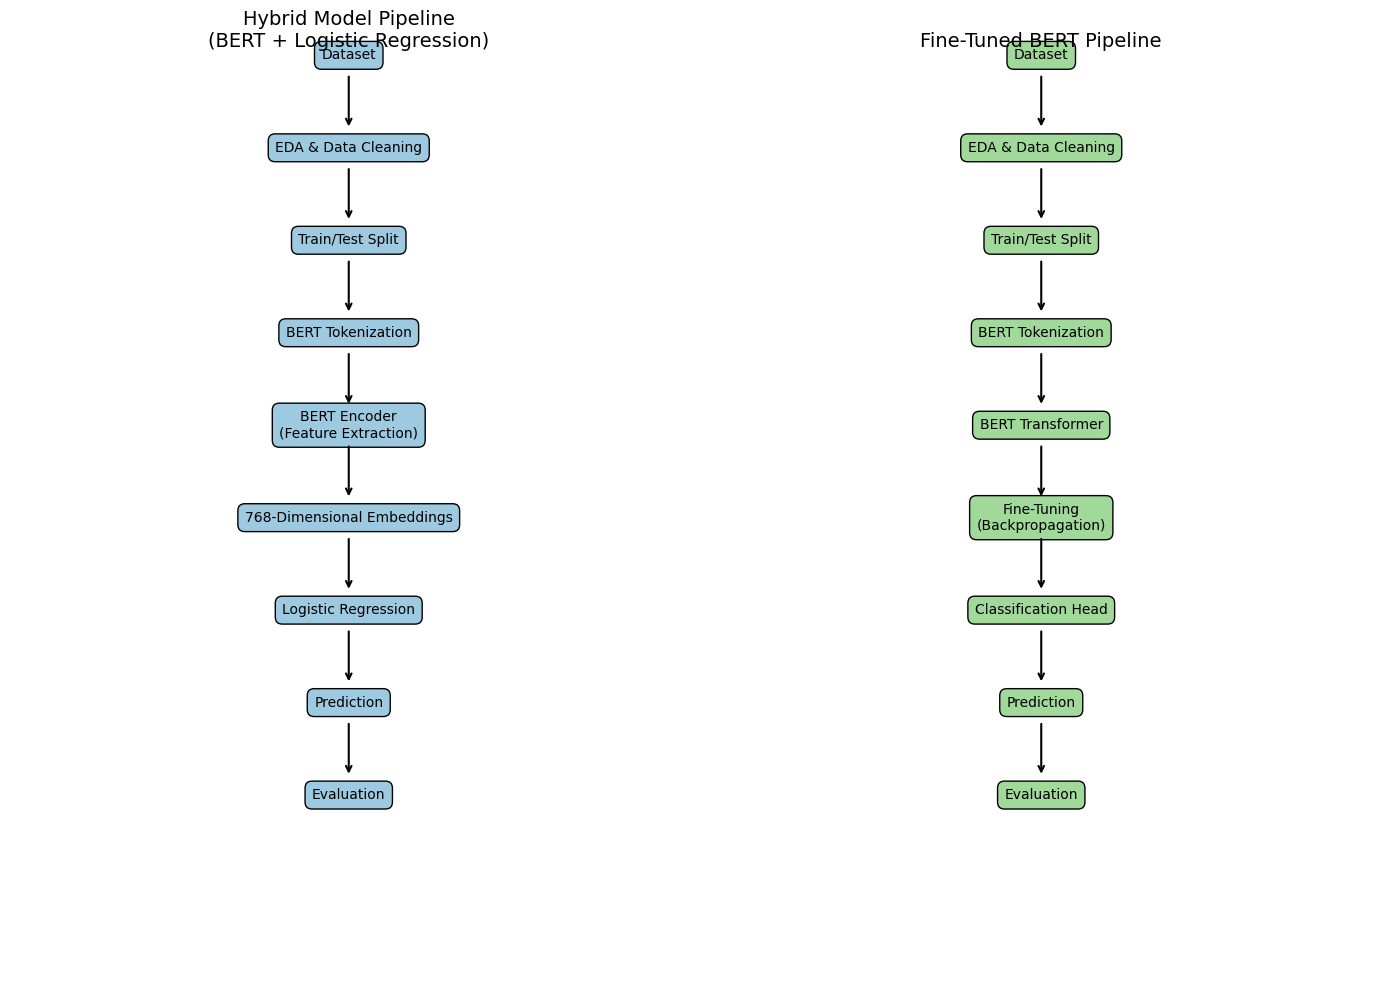

In [48]:
import matplotlib.pyplot as plt

# Create figure with 2 subplots (side by side)
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

# -----------------------------
# HYBRID MODEL PIPELINE
# -----------------------------
hybrid_steps = [
    "Dataset",
    "EDA & Data Cleaning",
    "Train/Test Split",
    "BERT Tokenization",
    "BERT Encoder\n(Feature Extraction)",
    "768-Dimensional Embeddings",
    "Logistic Regression",
    "Prediction",
    "Evaluation"
]

ax = axes[0]

for i, step in enumerate(hybrid_steps):
    ax.text(
        0.5, 1 - i*0.1,
        step,
        ha='center',
        va='center',
        bbox=dict(boxstyle="round,pad=0.5", fc="#9ecae1", ec="black"),
        fontsize=10
    )

    if i < len(hybrid_steps) - 1:
        ax.annotate(
            "",
            xy=(0.5, 1-(i+1)*0.1+0.02),
            xytext=(0.5, 1-i*0.1-0.02),
            arrowprops=dict(arrowstyle="->", lw=1.5)
        )

ax.set_title("Hybrid Model Pipeline\n(BERT + Logistic Regression)", fontsize=14)
ax.axis("off")


# -----------------------------
# FINE-TUNED BERT PIPELINE
# -----------------------------
finetune_steps = [
    "Dataset",
    "EDA & Data Cleaning",
    "Train/Test Split",
    "BERT Tokenization",
    "BERT Transformer",
    "Fine-Tuning\n(Backpropagation)",
    "Classification Head",
    "Prediction",
    "Evaluation"
]

ax = axes[1]

for i, step in enumerate(finetune_steps):
    ax.text(
        0.5, 1 - i*0.1,
        step,
        ha='center',
        va='center',
        bbox=dict(boxstyle="round,pad=0.5", fc="#a1d99b", ec="black"),
        fontsize=10
    )

    if i < len(finetune_steps) - 1:
        ax.annotate(
            "",
            xy=(0.5, 1-(i+1)*0.1+0.02),
            xytext=(0.5, 1-i*0.1-0.02),
            arrowprops=dict(arrowstyle="->", lw=1.5)
        )

ax.set_title("Fine-Tuned BERT Pipeline", fontsize=14)
ax.axis("off")

plt.tight_layout()
plt.show()



## Overall Project Conclusion

This project developed a machine learning system to classify civic policy descriptions as **High Impact** or **Low Impact** using Natural Language Processing techniques.

The workflow followed a complete machine learning pipeline including data inspection, exploratory data analysis, data cleaning, feature engineering, and model development.

### Key Steps Completed

1. **Dataset Exploration**
   - The dataset initially contained **3000 records** with significant duplicate policy texts.
   - Exploratory Data Analysis revealed that more than **50% of the records were duplicates**, which could lead to data leakage during model training.

2. **Data Cleaning**
   - Duplicate policy texts were removed.
   - The dataset was reduced to **1249 unique policy descriptions**.
   - This ensured that the model learned meaningful patterns instead of memorizing repeated examples.

3. **Feature Engineering**
   - Additional text-based features were created, including:
     - Character length
     - Word count
   - These helped analyze the structure and distribution of the policy texts.

4. **Hybrid Model Development**
   - A hybrid NLP architecture was implemented:
     
     BERT Embeddings → Logistic Regression Classifier

   - BERT was used to extract contextual semantic embeddings from policy text.
   - Logistic Regression classified these embeddings into impact categories.

5. **Fine-Tuned Transformer Model**
   - A pretrained **BERT Base Uncased** model was fine-tuned on the cleaned dataset.
   - Fine-tuning allowed the transformer weights to adapt to the civic policy classification task.

### Model Performance

Both approaches demonstrated excellent performance on the test dataset.

| Model | Approach | Accuracy |
|------|------|------|
| BERT Embeddings + Logistic Regression | Hybrid Model | 1.00 |
| Fine-Tuned BERT | End-to-End Transformer | 1.00 |

### Key Insights

- Transformer-based models are highly effective for **policy text classification tasks**.
- Removing duplicate records significantly improves **model reliability and evaluation validity**.
- Hybrid architectures combining deep learning embeddings with classical machine learning classifiers can provide **efficient and interpretable solutions**.

### Final Observation

Although the models achieved perfect performance on the test set, the dataset size after cleaning was relatively small. For real-world deployment, the system would benefit from:

- Larger and more diverse policy datasets
- Additional validation techniques such as cross-validation
- Testing on real policy documents from different jurisdictions

### Final Outcome

The project successfully demonstrates how **modern transformer-based NLP techniques** can be applied to analyze civic policy text and support transparent governance through automated impact classification.

